In [ ]:
!git clone https://github.com/yuqinie98/PatchTST.git /content/PatchTST
%cd /content/PatchTST/PatchTST_supervised
!sed -i '/torch==1.11.0/d' requirements.txt
!pip install -r requirements.txt -q
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q

Cloning into '/content/PatchTST'...
remote: Enumerating objects: 352, done.
remote: Total 352 (delta 0), reused 0 (delta 0), pack-reused 352 (from 1)
Receiving objects: 100% (352/352), 12.92 MiB | 20.30 MiB/s, done.
Resolving deltas: 100% (155/155), done.
/content/PatchTST/PatchTST_supervised


In [ ]:
path = "/content/PatchTST/PatchTST_supervised/utils/tools.py"
with open(path, "r") as f:
    code = f.read()
fixed = code.replace("np.Inf", "np.inf")
with open(path, "w") as f:
    f.write(fixed)
print("Fixed np.Inf -> np.inf")

Fixed np.Inf -> np.inf


In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler

os.makedirs("dataset", exist_ok=True)

ETT_FEATURES   = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
ETT_TARGET     = "OT"
ETT_TARGET_IDX = ETT_FEATURES.index(ETT_TARGET)

#download
!wget -q https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv \
     -O dataset/ETTh1.csv
df_ett = pd.read_csv("dataset/ETTh1.csv")
print(f"ETTh1 shape: {df_ett.shape}")

#split
BORDER2_TRAIN = 12 * 30 * 24          # end of train  = 8640
BORDER1_TEST  = 12 * 30 * 24 + 4 * 30 * 24  # start of test = 11520

n  = len(df_ett)
t  = np.arange(n, dtype=float)
t0 = int(BORDER2_TRAIN * 0.5)         # midpoint of training window

p95_train = np.percentile(df_ett[ETT_TARGET].iloc[:BORDER2_TRAIN].values, 95)
A = 10.0 * p95_train

print(f"n={n}  train ends={BORDER2_TRAIN}  test starts={BORDER1_TEST}")
print(f"Spike centre t0={t0}")
print(f"95th-pct OT (train) = {p95_train:.3f}  →  A = {A:.3f}")

# ── 3. Sigma variants (positive spike) ────────────────────────────────────
SIGMA_VARIANTS = [
    ("sigma_1",    1),
    ("sigma_4",    4),
    ("sigma_16",  16),
    ("sigma_32",  32),
    ("sigma_64",  64),
    ("sigma_128", 128),
]

spike_datasets = {}
for label, sigma in SIGMA_VARIANTS:
    S = A * np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))
    df_variant = df_ett.copy()
    df_variant.loc[df_variant.index < BORDER1_TEST, ETT_TARGET] = (
        df_variant.loc[df_variant.index < BORDER1_TEST, ETT_TARGET] + S[:BORDER1_TEST]
    )
    csv_path = f"dataset/ETTh1_{label}.csv"
    df_variant.to_csv(csv_path, index=False)
    spike_datasets[label] = csv_path
    print(f"Saved {csv_path}  (sigma={sigma:>3d}h, spike max={S.max():.3f})")

spike_datasets_neg = {}
for label, sigma in SIGMA_VARIANTS:
    S = A * np.exp(-((t - t0) ** 2) / (2 * sigma ** 2))
    df_variant = df_ett.copy()
    df_variant.loc[df_variant.index < BORDER1_TEST, ETT_TARGET] = (
        df_variant.loc[df_variant.index < BORDER1_TEST, ETT_TARGET] - S[:BORDER1_TEST]
    )
    csv_path = f"dataset/ETTh1_{label}_neg.csv"
    df_variant.to_csv(csv_path, index=False)
    spike_datasets_neg[label] = csv_path
    print(f"Saved {csv_path}  (negative spike, sigma={sigma:>3d}h)")



clean_data    = df_ett[ETT_FEATURES].values.astype(float)
scaler_clean  = StandardScaler()
scaler_clean.fit(clean_data[:BORDER2_TRAIN])

clean_mean = scaler_clean.mean_
clean_std  = scaler_clean.scale_
np.save("dataset/etth1_clean_scaler_mean.npy", clean_mean)
np.save("dataset/etth1_clean_scaler_std.npy",  clean_std)
print(f"\nClean scaler saved  (OT: mean={clean_mean[ETT_TARGET_IDX]:.3f}, std={clean_std[ETT_TARGET_IDX]:.3f})")
print("\nAll datasets ready:", os.listdir("dataset"))

ETTh1 shape: (17420, 8)
n=17420  train ends=8640  test starts=11520
Spike centre t0=4320
95th-pct OT (train) = 35.314  →  A = 353.140
Saved dataset/ETTh1_sigma_1.csv  (sigma=  1h, spike max=353.140)
Saved dataset/ETTh1_sigma_4.csv  (sigma=  4h, spike max=353.140)
Saved dataset/ETTh1_sigma_16.csv  (sigma= 16h, spike max=353.140)
Saved dataset/ETTh1_sigma_32.csv  (sigma= 32h, spike max=353.140)
Saved dataset/ETTh1_sigma_64.csv  (sigma= 64h, spike max=353.140)
Saved dataset/ETTh1_sigma_128.csv  (sigma=128h, spike max=353.140)
Saved dataset/ETTh1_sigma_1_neg.csv  (negative spike, sigma=  1h)
Saved dataset/ETTh1_sigma_4_neg.csv  (negative spike, sigma=  4h)
Saved dataset/ETTh1_sigma_16_neg.csv  (negative spike, sigma= 16h)
Saved dataset/ETTh1_sigma_32_neg.csv  (negative spike, sigma= 32h)
Saved dataset/ETTh1_sigma_64_neg.csv  (negative spike, sigma= 64h)
Saved dataset/ETTh1_sigma_128_neg.csv  (negative spike, sigma=128h)

Clean scaler saved  (OT: mean=17.128, std=9.176)

All datasets ready:

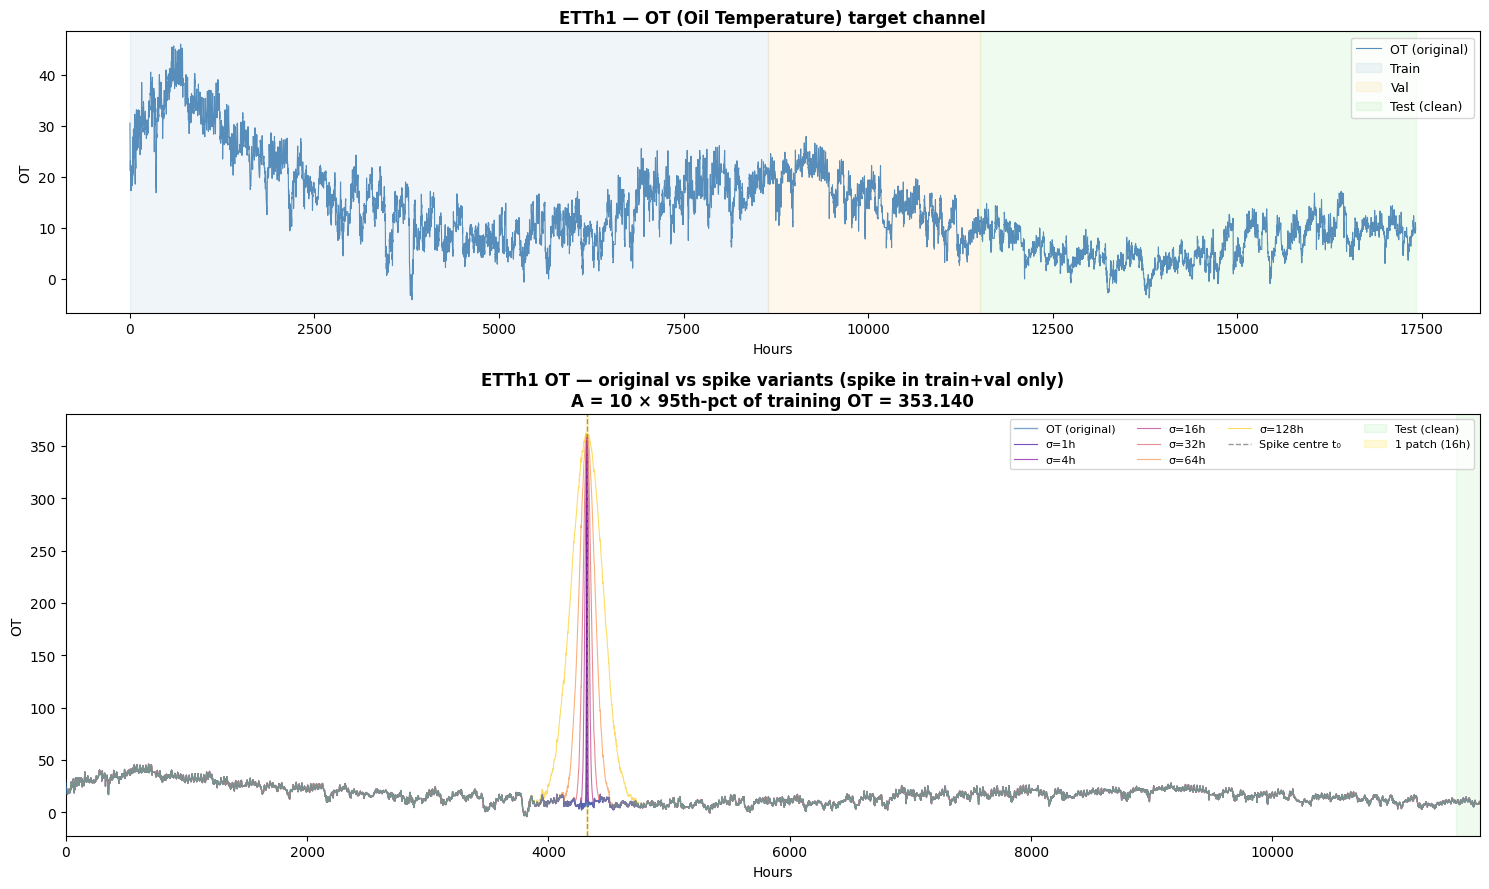

Saved: etth1_spike_variants.png


In [ ]:
import matplotlib.pyplot as plt

df_ett = pd.read_csv("dataset/ETTh1.csv")
n      = len(df_ett)
x      = np.arange(n)

fig, axes = plt.subplots(2, 1, figsize=(15, 9),
                         gridspec_kw={"height_ratios": [2, 3]})

ax = axes[0]
ax.plot(x, df_ett[ETT_TARGET], color="steelblue", linewidth=0.8, alpha=0.9, label="OT (original)")
ax.axvspan(0,             BORDER2_TRAIN, alpha=0.08, color="steelblue", label="Train")
ax.axvspan(BORDER2_TRAIN, BORDER1_TEST,  alpha=0.08, color="orange",    label="Val")
ax.axvspan(BORDER1_TEST,  n,             alpha=0.08, color="limegreen",  label="Test (clean)")
ax.set_title("ETTh1 — OT (Oil Temperature) target channel", fontweight="bold", fontsize=12)
ax.set_ylabel("OT"); ax.set_xlabel("Hours"); ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(x, df_ett[ETT_TARGET], color="steelblue", linewidth=1.0,
         alpha=0.7, label="OT (original)", zorder=5)

spike_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(SIGMA_VARIANTS)))
for (label, sigma), color in zip(SIGMA_VARIANTS, spike_colors):
    df_v = pd.read_csv(spike_datasets[label])
    ax2.plot(x, df_v[ETT_TARGET], color=color, linewidth=0.8, alpha=0.7, label=f"\u03c3={sigma}h")

ax2.axvline(t0, color="grey", linestyle="--", linewidth=1, alpha=0.8, label="Spike centre t\u2080")
ax2.axvspan(BORDER1_TEST, n, alpha=0.08, color="limegreen", label="Test (clean)")
ax2.axvspan(t0 - 8, t0 + 8, alpha=0.15, color="gold", label="1 patch (16h)")
ax2.set_xlim(0, BORDER1_TEST + 200)   # zoom out of test region slightly
ax2.set_title(
    "ETTh1 OT — original vs spike variants (spike in train+val only)\n"
    f"A = 10 × 95th-pct of training OT = {A:.3f}",
    fontweight="bold", fontsize=12)
ax2.set_ylabel("OT"); ax2.set_xlabel("Hours")
ax2.legend(fontsize=8, ncol=4, loc="upper right")

plt.tight_layout()
plt.savefig("etth1_spike_variants.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: etth1_spike_variants.png")

In [ ]:
!python run_longExp.py \
  --is_training 1 --root_path ./dataset/ --data_path ETTh1.csv \
  --model_id etth1_patchtst --model PatchTST --data ETTh1 --features M \
  --seq_len 336 --label_len 168 --pred_len 96 \
  --enc_in 7 --dec_in 7 --c_out 7 \
  --d_model 16 --n_heads 4 --e_layers 3 --d_ff 128 \
  --dropout 0.3 --fc_dropout 0.3 --head_dropout 0 \
  --patch_len 16 --stride 8 \
  --batch_size 128 --learning_rate 0.0001 --train_epochs 10 --itr 1

!python run_longExp.py \
  --is_training 1 --root_path ./dataset/ --data_path ETTh1.csv \
  --model_id etth1_transformer --model Transformer --data ETTh1 --features M \
  --seq_len 336 --label_len 168 --pred_len 96 \
  --enc_in 7 --dec_in 7 --c_out 7 \
  --d_model 16 --n_heads 4 --e_layers 3 --d_ff 128 \
  --dropout 0.3 --fc_dropout 0.3 \
  --batch_size 128 --learning_rate 0.0001 --train_epochs 10 --itr 1

for label, sigma in SIGMA_VARIANTS:
    !python run_longExp.py \
      --is_training 1 --root_path ./dataset/ \
      --data_path ETTh1_{label}.csv \
      --model_id spike_{label}_patchtst --model PatchTST --data ETTh1 --features M \
      --seq_len 336 --label_len 168 --pred_len 96 \
      --enc_in 7 --dec_in 7 --c_out 7 \
      --d_model 16 --n_heads 4 --e_layers 3 --d_ff 128 \
      --dropout 0.3 --fc_dropout 0.3 --head_dropout 0 \
      --patch_len 16 --stride 8 \
      --batch_size 128 --learning_rate 0.0001 --train_epochs 10 --itr 1

    !python run_longExp.py \
      --is_training 1 --root_path ./dataset/ \
      --data_path ETTh1_{label}.csv \
      --model_id spike_{label}_transformer --model Transformer --data ETTh1 --features M \
      --seq_len 336 --label_len 168 --pred_len 96 \
      --enc_in 7 --dec_in 7 --c_out 7 \
      --d_model 16 --n_heads 4 --e_layers 3 --d_ff 128 \
      --dropout 0.3 --fc_dropout 0.3 \
      --batch_size 128 --learning_rate 0.0001 --train_epochs 10 --itr 1

for label, sigma in SIGMA_VARIANTS:
    !python run_longExp.py \
      --is_training 1 --root_path ./dataset/ \
      --data_path ETTh1_{label}_neg.csv \
      --model_id spike_{label}_neg_patchtst --model PatchTST --data ETTh1 --features M \
      --seq_len 336 --label_len 168 --pred_len 96 \
      --enc_in 7 --dec_in 7 --c_out 7 \
      --d_model 16 --n_heads 4 --e_layers 3 --d_ff 128 \
      --dropout 0.3 --fc_dropout 0.3 --head_dropout 0 \
      --patch_len 16 --stride 8 \
      --batch_size 128 --learning_rate 0.0001 --train_epochs 10 --itr 1

    !python run_longExp.py \
      --is_training 1 --root_path ./dataset/ \
      --data_path ETTh1_{label}_neg.csv \
      --model_id spike_{label}_neg_transformer --model Transformer --data ETTh1 --features M \
      --seq_len 336 --label_len 168 --pred_len 96 \
      --enc_in 7 --dec_in 7 --c_out 7 \
      --d_model 16 --n_heads 4 --e_layers 3 --d_ff 128 \
      --dropout 0.3 --fc_dropout 0.3 \
      --batch_size 128 --learning_rate 0.0001 --train_epochs 10 --itr 1

print("All training runs complete.")

Args in experiment:
Namespace(random_seed=2021, is_training=1, model_id='etth1_patchtst', model='PatchTST', data='ETTh1', root_path='./dataset/', data_path='ETTh1.csv', features='M', target='OT', freq='h', checkpoints='./checkpoints/', seq_len=336, label_len=168, pred_len=96, fc_dropout=0.3, head_dropout=0.0, patch_len=16, stride=8, padding_patch='end', revin=1, affine=0, subtract_last=0, decomposition=0, kernel_size=25, individual=0, embed_type=0, enc_in=7, dec_in=7, c_out=7, d_model=16, n_heads=4, e_layers=3, d_layers=1, d_ff=128, moving_avg=25, factor=1, distil=True, dropout=0.3, embed='timeF', activation='gelu', output_attention=False, do_predict=False, num_workers=10, itr=1, train_epochs=10, batch_size=128, patience=100, learning_rate=0.0001, des='test', loss='mse', lradj='type3', pct_start=0.3, use_amp=False, use_gpu=True, gpu=0, use_multi_gpu=False, devices='0,1,2,3', test_flop=False)
Use GPU: cuda:0
>>>>>>>start training : etth1_patchtst_PatchTST_ETTh1_ftM_sl336_ll168_pl96_dm16

In [ ]:
import glob

results_dir = "./results"

def reconstruct_true_etth1(csv_path, seq_len=336, pred_len=96):
    """Reconstruct normalised ground-truth windows for ETTh1 test split."""
    df   = pd.read_csv(csv_path)
    data = df[ETT_FEATURES].values.astype(float)
    border2_train = 12 * 30 * 24
    border1_test  = 12 * 30 * 24 + 4 * 30 * 24 - seq_len
    scaler = StandardScaler()
    scaler.fit(data[:border2_train])
    data      = scaler.transform(data)
    test_data = data[border1_test:]
    return np.array([test_data[i+seq_len : i+seq_len+pred_len]
                     for i in range(len(test_data) - seq_len - pred_len + 1)])

baseline_results = {}
for folder in sorted(os.listdir(results_dir)):
    fp     = os.path.join(results_dir, folder)
    pred_p = os.path.join(fp, "pred.npy")
    if not os.path.isdir(fp) or not os.path.exists(pred_p): continue
    if not folder.startswith("etth1_"): continue
    model = "PatchTST" if "patchtst" in folder else "Transformer"
    pred  = np.load(pred_p)
    true  = reconstruct_true_etth1("./dataset/ETTh1.csv")
    true  = true[:len(pred)]
    baseline_results[model] = {"pred": pred, "true": true}
    ch  = ETT_TARGET_IDX
    mae = np.mean(np.abs(pred[:, :, ch] - true[:, :, ch]))
    print(f"Baseline {model}: pred={pred.shape}  MAE(OT)={mae:.4f}")

Baseline PatchTST: pred=(2688, 96, 7)  MAE(OT)=0.1761
Baseline Transformer: pred=(2688, 96, 7)  MAE(OT)=0.4725


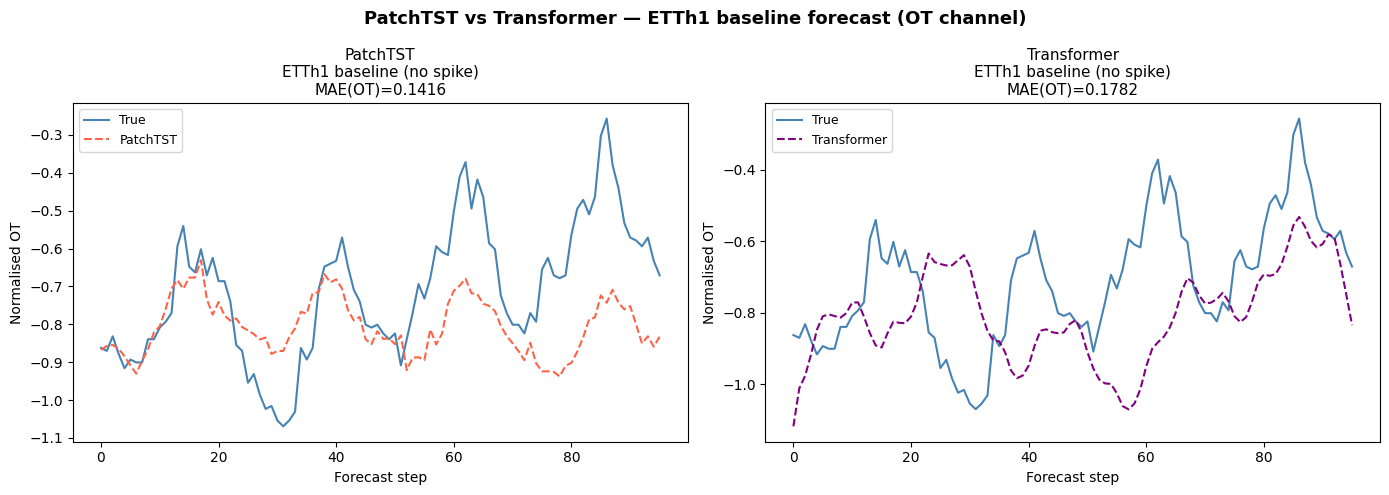

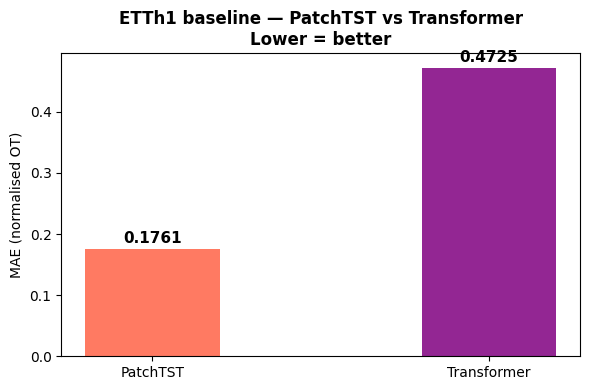


── Baseline Results ──
Model               MAE        MSE     RMSE
--------------------------------------------
PatchTST         0.1761     0.0540   0.2324
Transformer      0.4725     0.2908   0.5393


In [ ]:
colors = {"PatchTST": "tomato", "Transformer": "purple"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for col, model in enumerate(["PatchTST", "Transformer"]):
    ax  = axes[col]
    if model not in baseline_results:
        ax.set_title(f"{model} — missing"); continue
    ch   = ETT_TARGET_IDX
    pred = baseline_results[model]["pred"][0, :, ch]
    true = baseline_results[model]["true"][0, :, ch]
    mae  = np.mean(np.abs(pred - true))
    ax.plot(true, label="True", color="steelblue", linewidth=1.5)
    ax.plot(pred, label=model, color=colors[model], linestyle="--", linewidth=1.5)
    ax.set_title(f"{model}\nETTh1 baseline (no spike)\nMAE(OT)={mae:.4f}", fontsize=11)
    ax.legend(fontsize=9); ax.set_xlabel("Forecast step"); ax.set_ylabel("Normalised OT")
plt.suptitle("PatchTST vs Transformer — ETTh1 baseline forecast (OT channel)",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

#plot2
fig, ax = plt.subplots(figsize=(6, 4))
ch = ETT_TARGET_IDX
maes = {m: np.mean(np.abs(baseline_results[m]["pred"][:, :, ch]
                          - baseline_results[m]["true"][:, :, ch]))
        for m in ["PatchTST", "Transformer"] if m in baseline_results}
bars = ax.bar(list(maes.keys()), list(maes.values()),
              color=[colors[m] for m in maes], alpha=0.85, width=0.4)
for bar, v in zip(bars, maes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{v:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("MAE (normalised OT)")
ax.set_title("ETTh1 baseline — PatchTST vs Transformer\nLower = better", fontweight="bold")
plt.tight_layout(); plt.show()

print("\n── Baseline Results ──")
print(f"{'Model':<14} {'MAE':>8} {'MSE':>10} {'RMSE':>8}")
print("-" * 44)
for model in ["PatchTST", "Transformer"]:
    if model not in baseline_results: continue
    p = baseline_results[model]["pred"][:, :, ch:ch+1]
    t = baseline_results[model]["true"][:, :, ch:ch+1]
    mae = np.mean(np.abs(p-t)); mse = np.mean((p-t)**2)
    print(f"{model:<14} {mae:>8.4f} {mse:>10.4f} {np.sqrt(mse):>8.4f}")

In [ ]:
sigma_vals  = [s   for _, s in SIGMA_VARIANTS]
labels_list = [lbl for lbl, _ in SIGMA_VARIANTS]

mae_results     = {"PatchTST": [], "Transformer": []}
mae_results_neg = {"PatchTST": [], "Transformer": []}
mse_results     = {"PatchTST": [], "Transformer": []}

for label in labels_list:
    for suffix, res_dict in [("", mae_results), ("_neg", mae_results_neg)]:
        csv_key = spike_datasets_neg[label] if suffix == "_neg" else spike_datasets[label]
        true    = reconstruct_true_etth1(csv_key)

        for model_tag, model_name in [("patchtst", "PatchTST"), ("transformer", "Transformer")]:
            matches   = glob.glob(f"./results/spike_{label}{suffix}_{model_tag}*/pred.npy")
            pred_path = matches[0] if matches else None
            if pred_path is None:
                print(f"WARNING: no pred.npy for {label}{suffix} / {model_name}")
                res_dict[model_name].append(np.nan)
                continue
            pred = np.load(pred_path)
            t_   = true[:len(pred)]
            ch   = ETT_TARGET_IDX
            mae  = float(np.mean(np.abs(pred[:, :, ch] - t_[:, :, ch])))
            res_dict[model_name].append(mae)
            tag = "NEG" if suffix == "_neg" else "POS"
            print(f"{label:12s} {tag} | {model_name:<14} | MAE={mae:.4f}")

print("\nAll spike results loaded.")

sigma_1      POS | PatchTST       | MAE=0.1557
sigma_1      POS | Transformer    | MAE=0.4857
sigma_1      NEG | PatchTST       | MAE=0.1538
sigma_1      NEG | Transformer    | MAE=0.4179
sigma_4      POS | PatchTST       | MAE=0.1209
sigma_4      POS | Transformer    | MAE=0.5016
sigma_4      NEG | PatchTST       | MAE=0.1174
sigma_4      NEG | Transformer    | MAE=0.3978
sigma_16     POS | PatchTST       | MAE=0.0767
sigma_16     POS | Transformer    | MAE=0.4893
sigma_16     NEG | PatchTST       | MAE=0.0709
sigma_16     NEG | Transformer    | MAE=0.4553
sigma_32     POS | PatchTST       | MAE=0.0585
sigma_32     POS | Transformer    | MAE=0.3871
sigma_32     NEG | PatchTST       | MAE=0.0524
sigma_32     NEG | Transformer    | MAE=0.4729
sigma_64     POS | PatchTST       | MAE=0.0433
sigma_64     POS | Transformer    | MAE=0.1998
sigma_64     NEG | PatchTST       | MAE=0.0383
sigma_64     NEG | Transformer    | MAE=0.4132
sigma_128    POS | PatchTST       | MAE=0.0311
sigma_128    

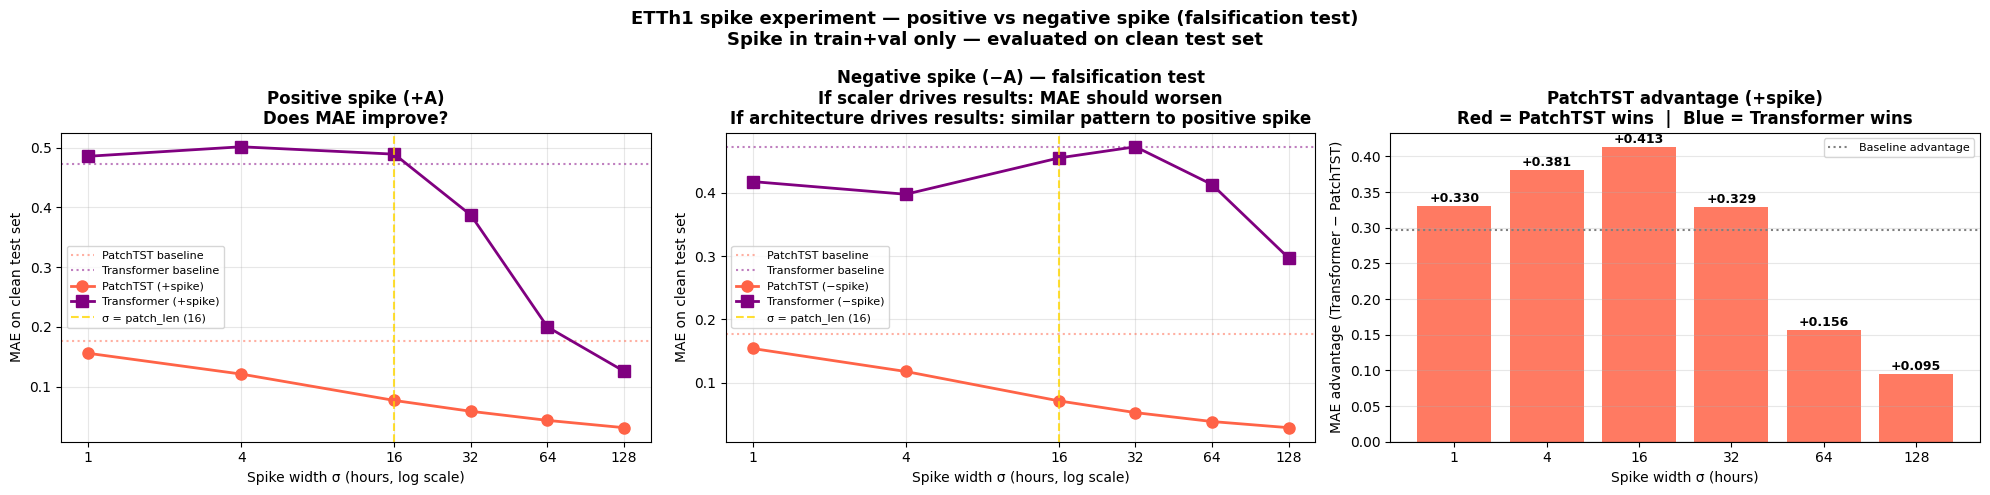

Saved: etth1_spike_width_mae.png


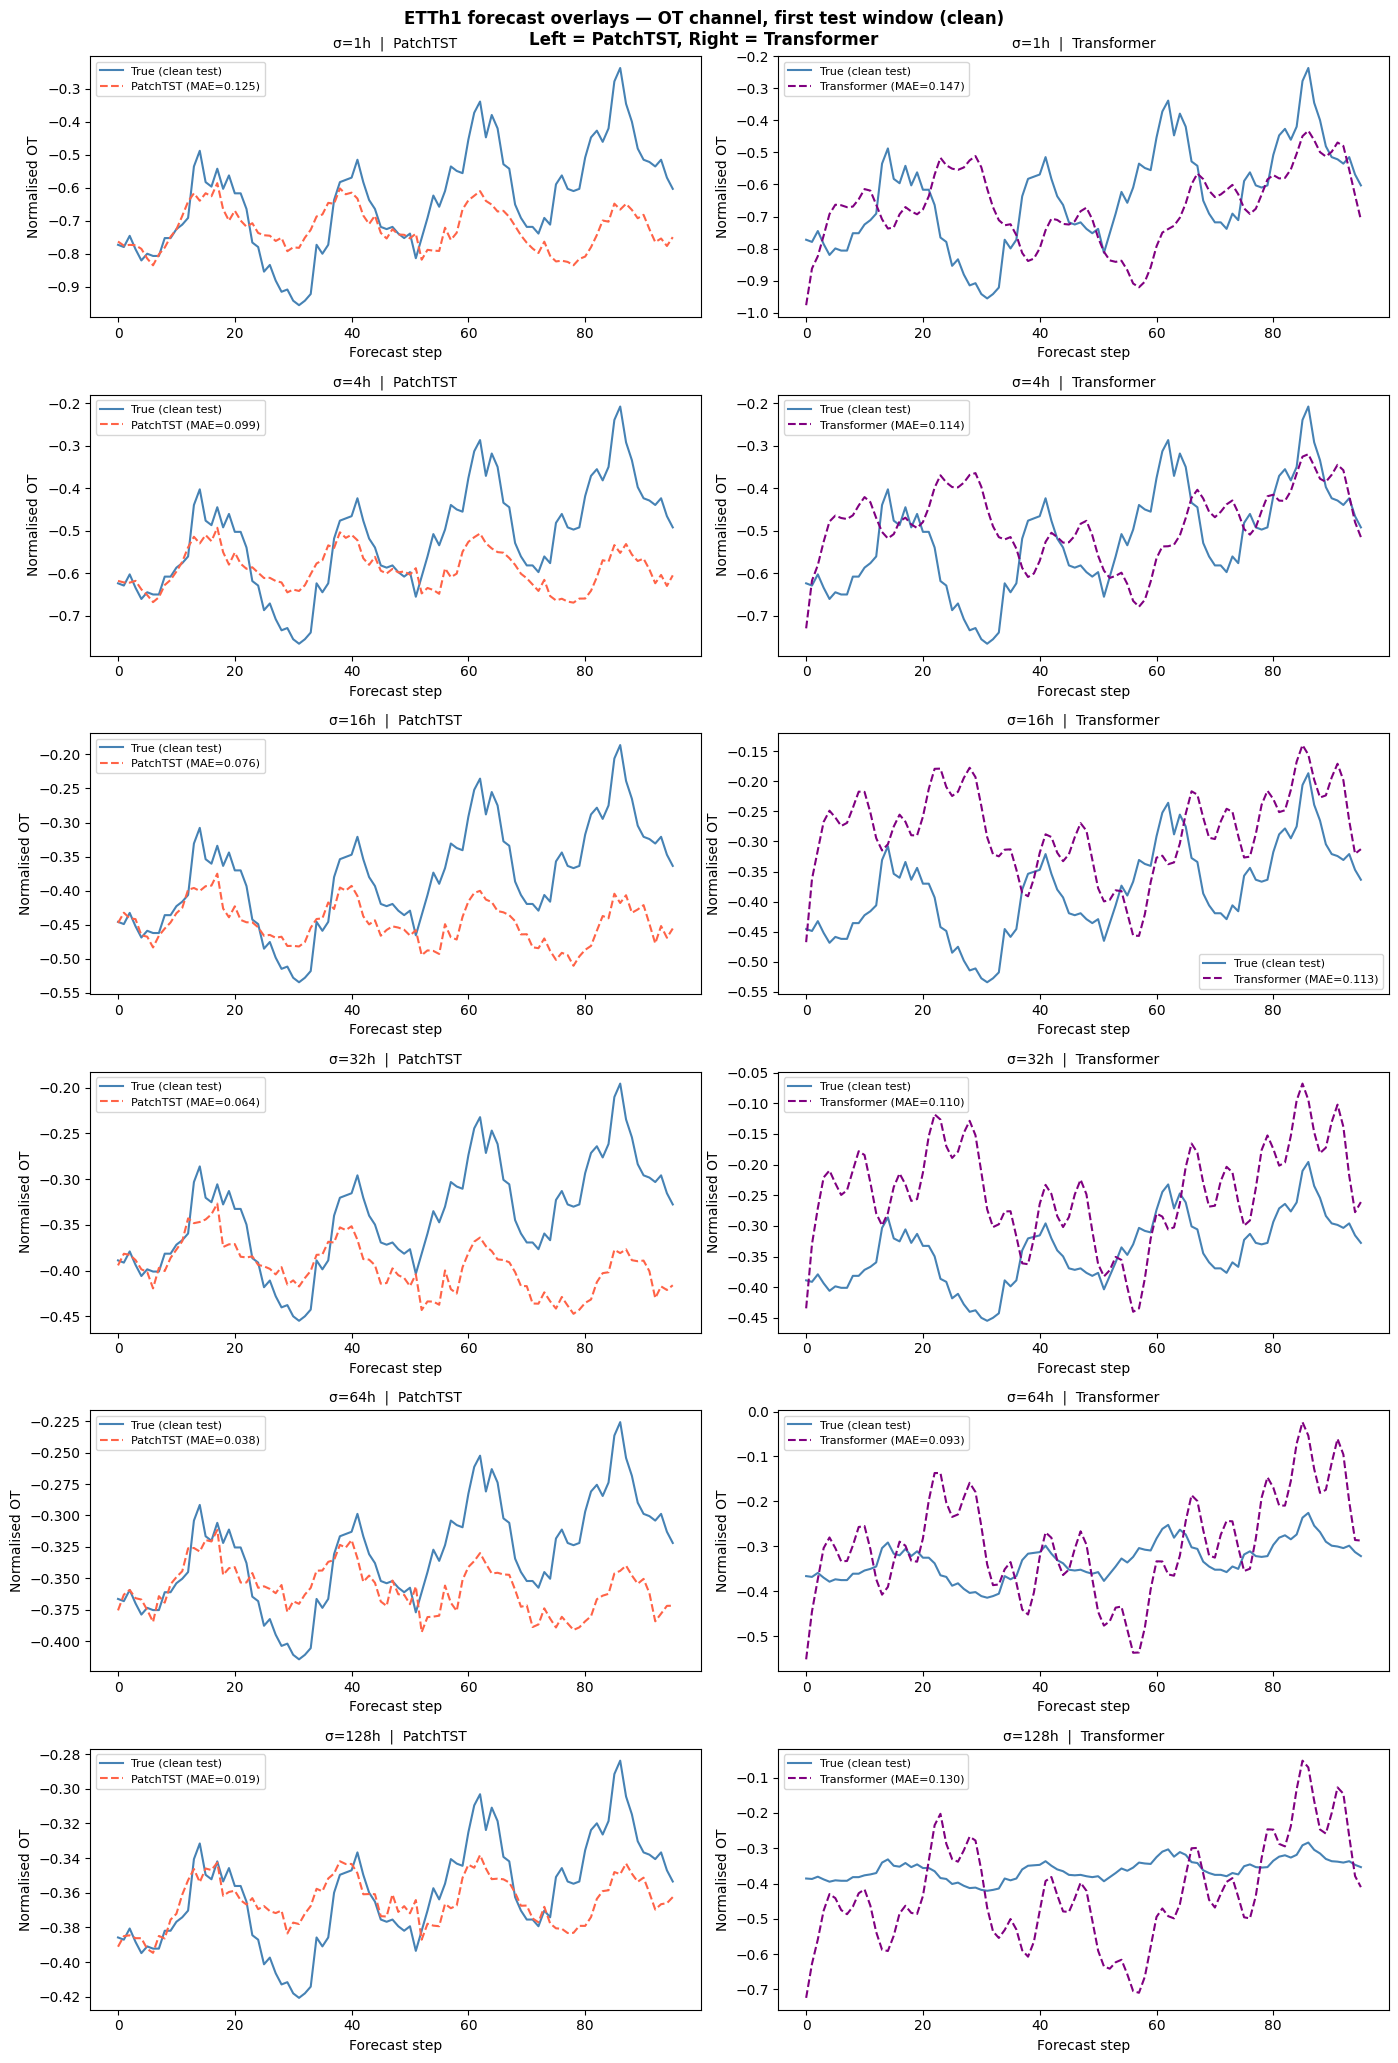


── Spike-Width Experiment Summary (ETTh1 OT) ──
Baseline: PatchTST=0.1761  Transformer=0.4725  Advantage=+0.2964

   σ (h)   cov    P_pos    T_pos   Adv_pos │    P_neg    T_neg   Adv_neg │ Falsification
------------------------------------------------------------------------------------------
       1  0.1x   0.1557   0.4857   +0.3300 │   0.1538   0.4179   +0.2641 │ ARCH (↓better/↓better)
       4  0.2x   0.1209   0.5016   +0.3808 │   0.1174   0.3978   +0.2804 │ ARCH (↓better/↓better)
      16  1.0x   0.0767   0.4893   +0.4126 │   0.0709   0.4553   +0.3843 │ ARCH (↓better/↓better)
      32  2.0x   0.0585   0.3871   +0.3286 │   0.0524   0.4729   +0.4206 │ ARCH (↓better/↑worse)
      64  4.0x   0.0433   0.1998   +0.1565 │   0.0383   0.4132   +0.3749 │ ARCH (↓better/↓better)
     128  8.0x   0.0311   0.1256   +0.0946 │   0.0285   0.2970   +0.2684 │ ARCH (↓better/↓better)

Falsification key:
  SCALER → positive spike improves, negative spike worsens  (scaler shift is driving MAE change)
 

In [ ]:
mae_patch     = np.array(mae_results["PatchTST"])
mae_trans     = np.array(mae_results["Transformer"])
mae_patch_neg = np.array(mae_results_neg["PatchTST"])
mae_trans_neg = np.array(mae_results_neg["Transformer"])
advantage     = mae_trans - mae_patch

ch = ETT_TARGET_IDX
base_patch = np.mean(np.abs(baseline_results["PatchTST"]["pred"][:, :, ch]
                            - baseline_results["PatchTST"]["true"][:, :, ch]))
base_trans = np.mean(np.abs(baseline_results["Transformer"]["pred"][:, :, ch]
                            - baseline_results["Transformer"]["true"][:, :, ch]))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]
ax.axhline(base_patch, color="tomato",  linestyle=":", linewidth=1.5, alpha=0.5, label="PatchTST baseline")
ax.axhline(base_trans, color="purple",  linestyle=":", linewidth=1.5, alpha=0.5, label="Transformer baseline")
ax.plot(sigma_vals, mae_patch, "o-", color="tomato",  linewidth=2, markersize=8, label="PatchTST (+spike)")
ax.plot(sigma_vals, mae_trans, "s-", color="purple",  linewidth=2, markersize=8, label="Transformer (+spike)")
ax.axvline(16, color="gold", linestyle="--", linewidth=1.5, alpha=0.8, label="\u03c3 = patch_len (16)")
ax.set_xscale("log", base=2); ax.set_xticks(sigma_vals)
ax.set_xticklabels([str(s) for s in sigma_vals])
ax.set_xlabel("Spike width \u03c3 (hours, log scale)"); ax.set_ylabel("MAE on clean test set")
ax.set_title("Positive spike (+A)\nDoes MAE improve?", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.axhline(base_patch, color="tomato",  linestyle=":", linewidth=1.5, alpha=0.5, label="PatchTST baseline")
ax2.axhline(base_trans, color="purple",  linestyle=":", linewidth=1.5, alpha=0.5, label="Transformer baseline")
ax2.plot(sigma_vals, mae_patch_neg, "o-", color="tomato",  linewidth=2, markersize=8, label="PatchTST (\u2212spike)")
ax2.plot(sigma_vals, mae_trans_neg, "s-", color="purple",  linewidth=2, markersize=8, label="Transformer (\u2212spike)")
ax2.axvline(16, color="gold", linestyle="--", linewidth=1.5, alpha=0.8, label="\u03c3 = patch_len (16)")
ax2.set_xscale("log", base=2); ax2.set_xticks(sigma_vals)
ax2.set_xticklabels([str(s) for s in sigma_vals])
ax2.set_xlabel("Spike width \u03c3 (hours, log scale)"); ax2.set_ylabel("MAE on clean test set")
ax2.set_title("Negative spike (\u2212A) — falsification test\nIf scaler drives results: MAE should worsen\nIf architecture drives results: similar pattern to positive spike",
              fontweight="bold")
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

ax3 = axes[2]
bar_colors = ["tomato" if v > 0 else "steelblue" for v in advantage]
ax3.bar([str(s) for s in sigma_vals], advantage, color=bar_colors, alpha=0.85)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(base_trans - base_patch, color="grey", linestyle=":",
            linewidth=1.5, label="Baseline advantage")
ax3.set_xlabel("Spike width \u03c3 (hours)")
ax3.set_ylabel("MAE advantage (Transformer \u2212 PatchTST)")
ax3.set_title("PatchTST advantage (+spike)\nRed = PatchTST wins  |  Blue = Transformer wins",
              fontweight="bold")
ax3.legend(fontsize=8); ax3.grid(True, axis="y", alpha=0.3)
for i, (s, v) in enumerate(zip(sigma_vals, advantage)):
    ax3.text(i, v + (0.002 if v >= 0 else -0.002), f"{v:+.3f}",
             ha="center", va="bottom" if v >= 0 else "top", fontsize=9, fontweight="bold")

plt.suptitle(
    "ETTh1 spike experiment — positive vs negative spike (falsification test)\n"
    "Spike in train+val only — evaluated on clean test set",
    fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("etth1_spike_width_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: etth1_spike_width_mae.png")

fig, axes = plt.subplots(len(SIGMA_VARIANTS), 2,
                         figsize=(14, 3.5 * len(SIGMA_VARIANTS)), sharey=False)
for row, (label, sigma) in enumerate(SIGMA_VARIANTS):
    true = reconstruct_true_etth1(spike_datasets[label])
    ch   = ETT_TARGET_IDX
    for col, (model_tag, model_name, color) in enumerate([
        ("patchtst", "PatchTST", "tomato"), ("transformer", "Transformer", "purple")
    ]):
        ax      = axes[row][col]
        matches = glob.glob(f"./results/spike_{label}_{model_tag}*/pred.npy")
        if not matches:
            ax.set_title(f"{model_name} / \u03c3={sigma} — no results"); continue
        pred = np.load(matches[0])
        t_   = true[:len(pred)]
        p0, tr0 = pred[0, :, ch], t_[0, :, ch]
        mae = np.mean(np.abs(p0 - tr0))
        ax.plot(tr0, color="steelblue", linewidth=1.5, label="True (clean test)")
        ax.plot(p0,  color=color, linestyle="--", linewidth=1.5,
                label=f"{model_name} (MAE={mae:.3f})")
        ax.set_title(f"\u03c3={sigma}h  |  {model_name}", fontsize=10)
        ax.legend(fontsize=8); ax.set_xlabel("Forecast step"); ax.set_ylabel("Normalised OT")
plt.suptitle("ETTh1 forecast overlays — OT channel, first test window (clean)\nLeft = PatchTST, Right = Transformer",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("etth1_spike_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

PATCH_LEN = 16
print("\n── Spike-Width Experiment Summary (ETTh1 OT) ──")
print(f"Baseline: PatchTST={base_patch:.4f}  Transformer={base_trans:.4f}  Advantage={base_trans-base_patch:+.4f}")
print()
print(f"{'\u03c3 (h)':>8} {'cov':>5} {'P_pos':>8} {'T_pos':>8} {'Adv_pos':>9} │ {'P_neg':>8} {'T_neg':>8} {'Adv_neg':>9} │ Falsification")
print("-" * 90)
for i, (label, sigma) in enumerate(SIGMA_VARIANTS):
    pp = mae_results["PatchTST"][i];     tp = mae_results["Transformer"][i]
    pn = mae_results_neg["PatchTST"][i]; tn = mae_results_neg["Transformer"][i]
    adv_p = tp - pp; adv_n = tn - pn
    neg_worse_patch = "↑worse" if pn > base_patch else "↓better"
    neg_worse_trans = "↑worse" if tn > base_trans else "↓better"
    driver = "SCALER" if (pn > base_patch and pp < base_patch) else "ARCH" if (pn < base_patch and pp < base_patch) else "MIXED"
    print(f"{sigma:>8d} {sigma/PATCH_LEN:>4.1f}x {pp:>8.4f} {tp:>8.4f} {adv_p:>+9.4f} │ {pn:>8.4f} {tn:>8.4f} {adv_n:>+9.4f} │ {driver} ({neg_worse_patch}/{neg_worse_trans})")

print()
print("Falsification key:")
print("  SCALER → positive spike improves, negative spike worsens  (scaler shift is driving MAE change)")
print("  ARCH   → both positive AND negative spike improve          (architecture / regularisation effect)")
print("  MIXED  → inconclusive")